In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [5]:
Fuel_cell_DF = pd.read_excel("/Users/arjun/Desktop/FC1_Ageing_part1.xlsx")
Fuel_cell_DF

,Time (h),U1 (V),U2 (V),U3 (V),U4 (V),U5 (V),Utot (V),J (A/cmｲ),I (A),TinH2 (ｰC),...,PinAIR (mbara),PoutAIR (mbara),PoutH2 (mbara),PinH2 (mbara),DinH2 (l/mn),DoutH2 (l/mn),DinAIR (l/mn),DoutAIR (l/mn),DWAT (l/mn),HrAIRFC (%)
0,0.000000,0.670,0.663,0.664,0.662,0.658,3.317,0.70164,70.164,25.930,...,1302.204,1269.602,1305.319,1292.489,4.799,2.115,23.038,21.331,2.020,48.904
1,0.000156,0.670,0.663,0.663,0.662,0.659,3.317,0.70164,70.164,25.945,...,1301.863,1269.829,1305.205,1292.432,4.799,2.115,23.036,21.331,2.019,48.901
2,0.000321,0.670,0.663,0.663,0.662,0.658,3.316,0.70168,70.168,25.943,...,1302.261,1269.773,1305.547,1293.059,4.801,2.115,23.038,21.331,2.016,48.913
3,0.000475,0.669,0.663,0.663,0.662,0.659,3.316,0.70164,70.164,25.945,...,1301.863,1269.886,1305.775,1292.945,4.797,2.114,23.036,21.350,2.016,48.894
4,0.000624,0.669,0.663,0.663,0.662,0.659,3.316,0.70159,70.159,25.939,...,1302.034,1269.659,1305.661,1293.002,4.797,2.116,23.036,21.331,2.017,48.939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65530,497.119418,0.657,0.654,0.648,0.653,0.650,3.262,0.70193,70.193,28.819,...,1300.555,1269.374,1302.410,1289.869,4.815,2.212,23.034,21.399,2.046,49.894
65531,497.127807,0.657,0.653,0.649,0.654,0.650,3.263,0.70198,70.198,28.819,...,1300.668,1268.521,1297.563,1284.230,4.797,2.171,23.036,21.401,2.031,49.857
65532,497.136208,0.657,0.654,0.649,0.653,0.650,3.263,0.70193,70.193,28.809,...,1300.441,1268.976,1294.312,1280.927,4.796,2.171,23.036,21.403,2.040,50.002
65533,497.144588,0.657,0.654,0.648,0.653,0.650,3.262,0.70178,70.178,28.810,...,1300.100,1268.577,1300.015,1286.850,4.795,2.089,23.038,21.401,2.036,50.238


<Axes: xlabel='minute'>

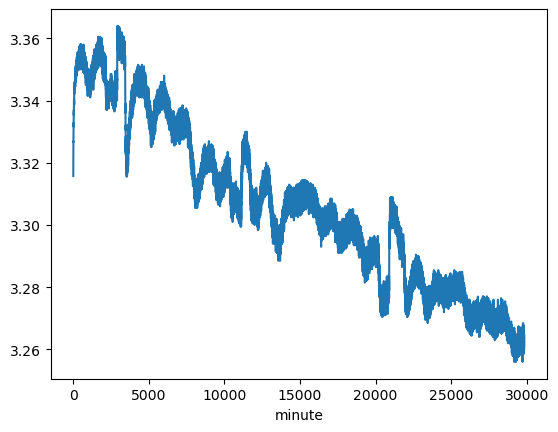

In [6]:
Fuel_cell_DF["Time (h)"] = Fuel_cell_DF["Time (h)"].astype("string")
Fuel_cell_DF["Time (h)"] = Fuel_cell_DF["Time (h)"].str.replace(",",".")
Fuel_cell_DF["Time (h)"] = Fuel_cell_DF["Time (h)"].astype("float")
Fuel_cell_DF["minute"] = (Fuel_cell_DF["Time (h)"]*60).apply(np.floor)
Fuel_cell_DF_cleaned = Fuel_cell_DF.groupby("minute").mean()
Fuel_cell_DF_cleaned["Utot (V)"].plot()


In [7]:
Fuel_cell_DF_cleaned.reset_index(inplace=True)
Fuel_cell_DF_cleaned.isna().sum()
Fuel_cell_DF_cleaned


,minute,Time (h),U1 (V),U2 (V),U3 (V),U4 (V),U5 (V),Utot (V),J (A/cmｲ),I (A),...,PinAIR (mbara),PoutAIR (mbara),PoutH2 (mbara),PinH2 (mbara),DinH2 (l/mn),DoutH2 (l/mn),DinAIR (l/mn),DoutAIR (l/mn),DWAT (l/mn),HrAIRFC (%)
0,0.0,0.007235,0.669121,0.663483,0.662983,0.662069,0.658086,3.315741,0.701622,70.162207,...,1301.270586,1269.165103,1298.663224,1285.830948,4.798086,2.145414,23.036483,21.400828,2.058776,49.333948
1,1.0,0.024878,0.669120,0.663860,0.663920,0.662900,0.658720,3.318520,0.701614,70.161380,...,1299.424960,1267.054700,1302.400200,1289.687920,4.798520,2.142000,23.037660,21.412520,2.044140,49.391000
2,2.0,0.041546,0.669020,0.663940,0.663960,0.662960,0.658980,3.318860,0.701605,70.160520,...,1299.295260,1266.577860,1296.147580,1282.615940,4.798840,2.148960,23.032740,21.400900,2.034640,49.556020
3,3.0,0.058215,0.669100,0.663900,0.664200,0.662980,0.658960,3.319140,0.701602,70.160160,...,1299.098440,1266.117960,1296.991560,1283.635600,4.797640,2.114660,23.032260,21.397840,1.984720,49.619680
4,4.0,0.074883,0.669460,0.664340,0.665000,0.663000,0.659020,3.320820,0.701599,70.159900,...,1300.543400,1267.466660,1299.045980,1285.808900,4.799420,2.120440,23.034320,21.401320,1.966540,49.453560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29825,29825.0,497.090054,0.656500,0.652500,0.649000,0.653000,0.650000,3.261000,0.701780,70.178000,...,1299.474000,1267.923000,1296.080500,1283.546500,4.807500,2.120000,23.038500,21.396000,2.037500,49.872000
29826,29826.0,497.106833,0.657000,0.654000,0.649500,0.653000,0.650500,3.264000,0.701880,70.188000,...,1297.454500,1266.329500,1302.895500,1290.723500,4.795500,2.110000,23.039000,21.402000,2.044000,49.995000
29827,29827.0,497.123613,0.657000,0.653500,0.648500,0.653500,0.650000,3.262500,0.701955,70.195500,...,1300.611500,1268.947500,1299.986500,1287.049500,4.806000,2.191500,23.035000,21.400000,2.038500,49.875500
29828,29828.0,497.140398,0.657000,0.654000,0.648500,0.653000,0.650000,3.262500,0.701855,70.185500,...,1300.270500,1268.776500,1297.163500,1283.888500,4.795500,2.130000,23.037000,21.402000,2.038000,50.120000


In [8]:
X = Fuel_cell_DF_cleaned.drop(["Utot (V)","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)","Time (h)"],axis=1).values
y = Fuel_cell_DF_cleaned["Utot (V)"].values
SEED = 1
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=SEED)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)
rf = RandomForestRegressor(n_estimators=400,random_state=SEED)
rf.fit(x_train_scaled,y_train)
y_pred = rf.predict(x_test_scaled)
rmse_test = mean_squared_error(y_test,y_pred)**(1/2)
print(rmse_test)


0.001980574930390552


In [9]:
gbr = GradientBoostingRegressor(random_state=SEED)
param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, 
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(x_train_scaled, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best RMSE: {-grid_search.best_score_:.6f}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400}
Best RMSE: 0.001800


In [10]:
y_pred_gbr = grid_search.predict(x_test_scaled)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr)**(1/2)
print(f"Gradient Boosting RMSE: {rmse_gbr:.6f}")
print(f"Improvement over Random Forest: {rmse_test - rmse_gbr:.6f}")

Gradient Boosting RMSE: 0.001778
Improvement over Random Forest: 0.000202


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65394 (\N{HALFWIDTH KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65392 (\N{HALFWIDTH KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


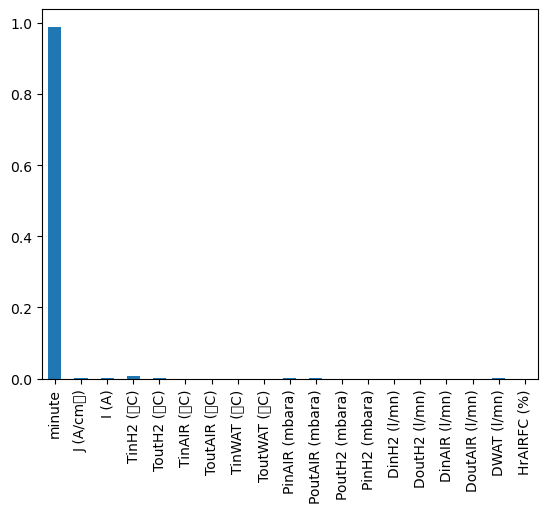

In [14]:
gbr.fit(x_train_scaled,y_train)
feature_names = Fuel_cell_DF_cleaned.drop(["Utot (V)","U1 (V)","U2 (V)","U3 (V)","U4 (V)","U5 (V)","Time (h)"],axis=1).columns 
importance_gbr = pd.Series(gbr.feature_importances_,index=feature_names)
importance_gbr.plot(kind="bar")
plt.show()

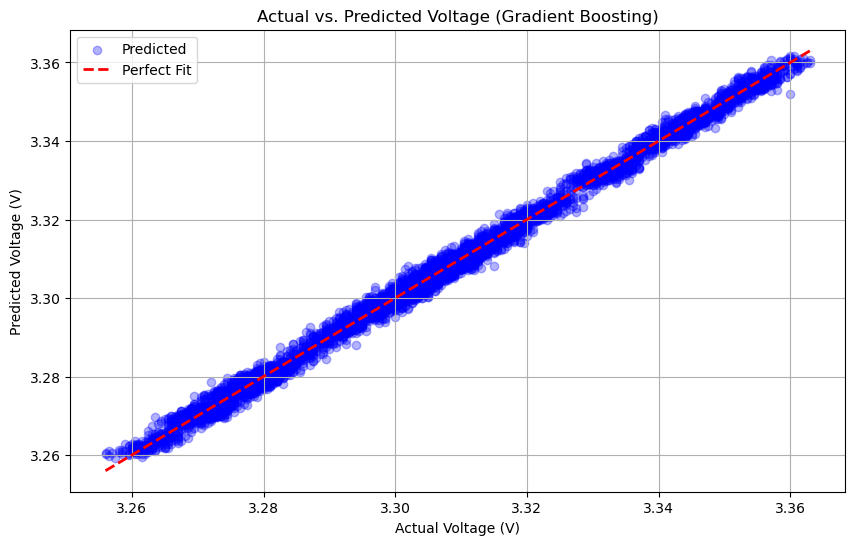

In [12]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted
plt.scatter(y_test, y_pred_gbr, alpha=0.3, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel("Actual Voltage (V)")
plt.ylabel("Predicted Voltage (V)")
plt.title("Actual vs. Predicted Voltage (Gradient Boosting)")
plt.legend()
plt.grid(True)
plt.show()